# The DNA-similarity premise

**Why sequence-specific DNA binding is hard — and where the signal actually is.**

The whole Sehgal et al. approach (and its rfd3na conditioning: ori tokens placed
toward the major groove + H-bond donor/acceptor conditioning on base-edge atoms)
rests on one structural fact about B-form DNA:

> The sugar-phosphate **backbone is essentially sequence-independent**. A protein
> cannot tell one base pair from another by backbone shape. The discriminating
> information lives on the **base edges exposed in the major groove** — the
> hydrogen-bond donor/acceptor/methyl pattern that differs between A:T, T:A, G:C
> and C:G.

This notebook establishes both halves quantitatively on a canonical B-DNA
dodecamer (the Drew–Dickerson dodecamer, PDB **1BNA**), the same reference our
target-prep geometry uses.

In [1]:
import urllib.request
import os

import numpy as np
import matplotlib.pyplot as plt

import biotite.structure as struc
import biotite.structure.io.pdbx as pdbx

## 1. Load the reference B-DNA dodecamer (PDB 1BNA)

In [2]:
CIF = "1bna.cif"
if not os.path.exists(CIF):
    urllib.request.urlretrieve("https://files.rcsb.org/download/1BNA.cif", CIF)

arr = pdbx.get_structure(pdbx.CIFFile.read(CIF), model=1)
dna = arr[struc.filter_nucleotides(arr)]
chA = dna[dna.chain_id == "A"]
resids = sorted(set(chA.res_id))
seq = "".join(chA[chA.res_id == r].res_name[0][-1] for r in resids)
print(f"Chain A: {len(resids)} nt, 5'->3' = {seq}")

Chain A: 12 nt, 5'->3' = CGCGAATTCGCG


## 2. Backbone degeneracy — base identity does not change backbone shape

For every interior nucleotide (those with a complete sugar–phosphate unit,
including the 5' phosphate), we superpose the 11-atom backbone unit onto every
other and record the RMSD. If backbone shape encoded sequence, **same-base** pairs
would superpose better than **different-base** pairs. They do not.

In [3]:
BB = ["P", "OP1", "OP2", "O5'", "C5'", "C4'", "C3'", "O3'", "C2'", "C1'", "O4'"]

units = {}
for rid in resids:
    r = chA[chA.res_id == rid]
    units[rid] = (r.res_name[0][-1], {a.atom_name: a.coord for a in r})

interior = [rid for rid in resids if all(a in units[rid][1] for a in BB)]
bases = [units[rid][0] for rid in interior]


def unit_coords(rid):
    return np.array([units[rid][1][a] for a in BB])


def kabsch_rmsd(a, b):
    ac, bc = a - a.mean(0), b - b.mean(0)
    H = ac.T @ bc
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    R = Vt.T @ np.diag([1, 1, d]) @ U.T
    return np.sqrt(np.mean(np.sum((ac @ R.T - bc) ** 2, axis=1)))


n = len(interior)
M = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        M[i, j] = kabsch_rmsd(unit_coords(interior[i]), unit_coords(interior[j]))

same = [M[i, j] for i in range(n) for j in range(i + 1, n) if bases[i] == bases[j]]
diff = [M[i, j] for i in range(n) for j in range(i + 1, n) if bases[i] != bases[j]]
print(f"backbone RMSD, same-base pairs:  {np.mean(same):.3f} +/- {np.std(same):.3f} A (n={len(same)})")
print(f"backbone RMSD, diff-base pairs:  {np.mean(diff):.3f} +/- {np.std(diff):.3f} A (n={len(diff)})")
print(f"max backbone RMSD across all interior nucleotides: {M[np.triu_indices(n, 1)].max():.3f} A")

backbone RMSD, same-base pairs:  0.328 +/- 0.106 A (n=11)
backbone RMSD, diff-base pairs:  0.320 +/- 0.105 A (n=44)
max backbone RMSD across all interior nucleotides: 0.610 A


**Result.** Same-base and different-base backbone RMSDs are indistinguishable
(both ~0.32 Å, well within the crystallographic coordinate error), and the
largest backbone deviation across all interior nucleotides is < 0.7 Å. Backbone
geometry carries **no usable sequence information**.

## 3. Where the signal is — major-groove base-edge chemistry

Each Watson–Crick base pair presents a distinct pattern of hydrogen-bond
donors (D), acceptors (A) and the thymine methyl (M) on its **major-groove edge**
(the Seeman–Rosenberg readout code). A protein that hydrogen-bonds into the major
groove *can* discriminate all four base pairs — which is exactly what rfd3na's
H-bond donor/acceptor conditioning targets.

In [4]:
# Major-groove edge signature per base pair (5'->3' reading, strand | complement).
bp_signatures = {
    "A:T": ["A:N7", "A:N6(D)", "T:O4(A)", "T:C7-methyl(M)"],
    "T:A": ["T:O4(A)", "T:C7-methyl(M)", "A:N7", "A:N6(D)"],
    "G:C": ["G:N7(A)", "G:O6(A)", "C:N4(D)"],
    "C:G": ["C:N4(D)", "G:N7(A)", "G:O6(A)"],
}
for bp, sig in bp_signatures.items():
    print(f"{bp}:  {'  '.join(sig)}")
print(f"\nDistinct major-groove signatures: {len(set(map(tuple, bp_signatures.values())))} of 4 base pairs")

A:T:  A:N7  A:N6(D)  T:O4(A)  T:C7-methyl(M)
T:A:  T:O4(A)  T:C7-methyl(M)  A:N7  A:N6(D)
G:C:  G:N7(A)  G:O6(A)  C:N4(D)
C:G:  C:N4(D)  G:N7(A)  G:O6(A)

Distinct major-groove signatures: 4 of 4 base pairs


## 4. Figure — the premise in one panel

The right panel encodes the major-groove edge as the **ordered** sequence of
chemical features read along the groove. This matters: A:T and T:A present the
*same* atom types but in opposite order (one is the mirror of the other), as do
G:C and C:G — so all four base pairs are distinguishable, which a
presence-only matrix would hide.

saved dna_similarity_premise.png
ordered readouts distinct across all 4 base pairs: True


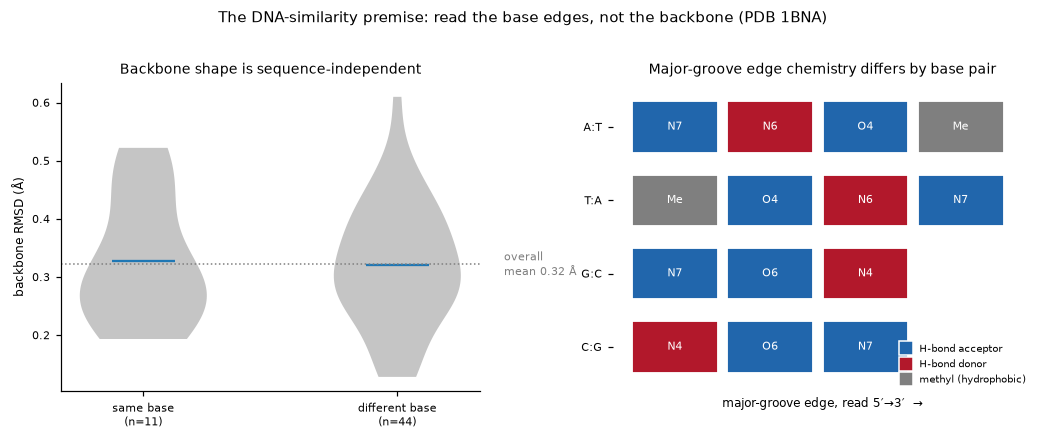

In [5]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# self-contained style (no external kernel helpers, so a fresh checkout re-runs)
META_GREY = "#7f7f7f"
plt.rcParams.update({
    "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 6.5,
    "axes.spines.top": False, "axes.spines.right": False,
})


def set_frame(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ordered major-groove readout (5'->3' along the groove): A=H-bond acceptor,
# D=H-bond donor, M=thymine methyl (hydrophobic). A:T is the mirror of T:A.
readout = {
    "A:T": [("N7", "A"), ("N6", "D"), ("O4", "A"), ("Me", "M")],
    "T:A": [("Me", "M"), ("O4", "A"), ("N6", "D"), ("N7", "A")],
    "G:C": [("N7", "A"), ("O6", "A"), ("N4", "D")],
    "C:G": [("N4", "D"), ("O6", "A"), ("N7", "A")],
}
ROLE_COLORS = {"A": "#2166AC", "D": "#B2182B", "M": "#7F7F7F"}  # acceptor / donor / methyl
ROLE_NAMES = {"A": "H-bond acceptor", "D": "H-bond donor", "M": "methyl (hydrophobic)"}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 4.0))

# --- Left: backbone RMSD distributions, same vs different base ---
parts = axL.violinplot([same, diff], showmeans=True, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor(META_GREY)
    pc.set_alpha(0.45)
axL.set_xticks([1, 2])
axL.set_xticklabels([f"same base\n(n={len(same)})", f"different base\n(n={len(diff)})"])
axL.set_ylabel("backbone RMSD (Å)")
axL.set_title("Backbone shape is sequence-independent")
grand = np.mean(same + diff)
axL.axhline(grand, ls=":", c=META_GREY, lw=1)
axL.text(2.42, grand, f"overall\nmean {grand:.2f} Å", va="center", ha="left",
         fontsize=7, color=META_GREY)
axL.margins(x=0.05)
set_frame(axL)

# --- Right: ordered major-groove readout strip, one row per base pair ---
for i, (bp, feats) in enumerate(readout.items()):
    y = len(readout) - 1 - i
    for j, (atom, role) in enumerate(feats):
        axR.add_patch(Rectangle((j, y - 0.35), 0.9, 0.7,
                                 facecolor=ROLE_COLORS[role], edgecolor="white", lw=1.2))
        txt_c = "white" if role != "M" else "white"
        axR.text(j + 0.45, y, atom, ha="center", va="center", color=txt_c, fontsize=7)
axR.set_xlim(-0.2, 4.2)
axR.set_ylim(-0.6, len(readout) - 0.4)
axR.set_yticks(range(len(readout)))
axR.set_yticklabels(list(readout.keys())[::-1])
axR.set_xticks([])
for sp in axR.spines.values():
    sp.set_visible(False)
axR.set_title("Major-groove edge chemistry differs by base pair")
axR.set_xlabel("major-groove edge, read 5′→3′  →")
# legend in whitespace (right margin)
handles = [Line2D([0], [0], marker="s", ls="", markerfacecolor=c,
                  markeredgecolor="white", markersize=9, label=ROLE_NAMES[r])
           for r, c in ROLE_COLORS.items()]
axR.legend(handles=handles, loc="lower right", frameon=False, fontsize=6.5,
           handletextpad=0.3, borderaxespad=0.2)

fig.suptitle("The DNA-similarity premise: read the base edges, not the backbone (PDB 1BNA)",
             fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("dna_similarity_premise.png", dpi=200, bbox_inches="tight")
print("saved dna_similarity_premise.png")
print("ordered readouts distinct across all 4 base pairs:",
      len({tuple(v) for v in readout.values()}) == 4)

## Takeaway

* **Backbone:** same-base vs different-base RMSD ≈ 0.32 Å either way — no signal.
* **Major groove:** each base pair has a distinct donor/acceptor/methyl edge.

Sequence-specific recognition therefore *must* read the major-groove base edges.
This is the structural justification for rfd3na's conditioning strategy in the
binder block: place the designed protein's centre of mass toward the major groove
(ori token) and condition backbone generation on the major-groove H-bond
donor/acceptor atoms of the target sequence. Note that A:T is the mirror image of
T:A (and G:C of C:G): they present the same feature *types* in opposite 5′→3′
order, so discrimination depends on the 3D placement of those atoms, not just
which atoms are present — which is why rfd3na conditions on atom coordinates, not
an atom list.